In [1]:
# Import dependencies

import tensorflow as tf 
import numpy as np
import matplotlib.pyplot as plt
import math

In [2]:
# Generating the data
# We will generate this many sample data points
SAMPLES = 1000
# Setting a "seed" value, so we get te same random numbers each time we run
# notebook. Any number can be used here
SEED = 1337
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Generate a uniformly distributed set of random numbers in the range from 
# 0 to 2n, which covers a complete sienwave oscillation.
x_value = np.random.uniform(low=0, high=2*math.pi, size=SAMPLES)

#Shuffle the values to guarantee they are not in order
np.random.shuffle(x_value)

# Calculate the corresponding sine wave
y_value = np.sin(x_value)

# Add a small random number to each y value 
y_values = y_value + 0.1 * np.random.randn(*y_value.shape)





In [3]:
# 60 % of our data will will be used for the training, 20% will be for testing
# the remaining 20% will be validation.
# Calculating the indeces of each section

Train_split = int(0.6 * SAMPLES)
Test_split = int(0.2 * SAMPLES + Train_split)

# Use np.split to chop our data into three parts.
# The second argument to np.split is an array of indices where the data will be 
# split. We provide two indices, so that data will be divided into three chunks

x_train, x_val, x_test = np.split(x_value, [Train_split, Test_split])
y_train, y_val, y_test = np.split(y_values, [Train_split, Test_split])

# Double checking that our splits add up correctly
assert(x_train.size + x_val.size + x_test.size) == SAMPLES

In [4]:
# Using keras to create a simple model architecture 
from tensorflow.keras import layers
model_1 = tf.keras.Sequential()

# First layer takes a scalar input and feeds it through 16 "neurons". The 
# neurons decide whether to activate based on "relu" activation function
model_1.add(layers.Dense(16, activation='relu', input_shape=(1,)))

# Final layer is a single neuron
model_1.add(layers.Dense(1))

# Compiling the model using a standard optimizer and loss function for linear regresssion
model_1.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])

# print model summary
model_1.summary()

c:\Users\tajbi\anaconda3\envs\tinyml\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49 (196.00 B)

 Trainable params: 49 (196.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Training the first model
history_1 = model_1.fit(x_train, y_train, epochs=1000, batch_size=16,
                        validation_data=(x_val, y_val))

Epoch 1/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3979 - mae: 0.5449 - val_loss: 0.3936 - val_mae: 0.5439
Epoch 2/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3519 - mae: 0.5150 - val_loss: 0.3508 - val_mae: 0.5104
Epoch 3/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3147 - mae: 0.4876 - val_loss: 0.3141 - val_mae: 0.4822
Epoch 4/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2832 - mae: 0.4635 - val_loss: 0.2833 - val_mae: 0.4575
Epoch 5/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2572 - mae: 0.4438 - val_loss: 0.2581 - val_mae: 0.4388
Epoch 6/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2365 - mae: 0.4274 - val_loss: 0.2382 - val_mae: 0.4239
Epoch 7/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2204 - mae: 0.4135 - val_loss: 0.2230 - val_mae: 0.4118
Epoch 8/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2085 - mae: 0.4031 - val_loss: 0.2118 - val_mae: 0.4024
Epoch 9/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - lo

In [6]:

pred_1 = model_1.predict(x_train)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


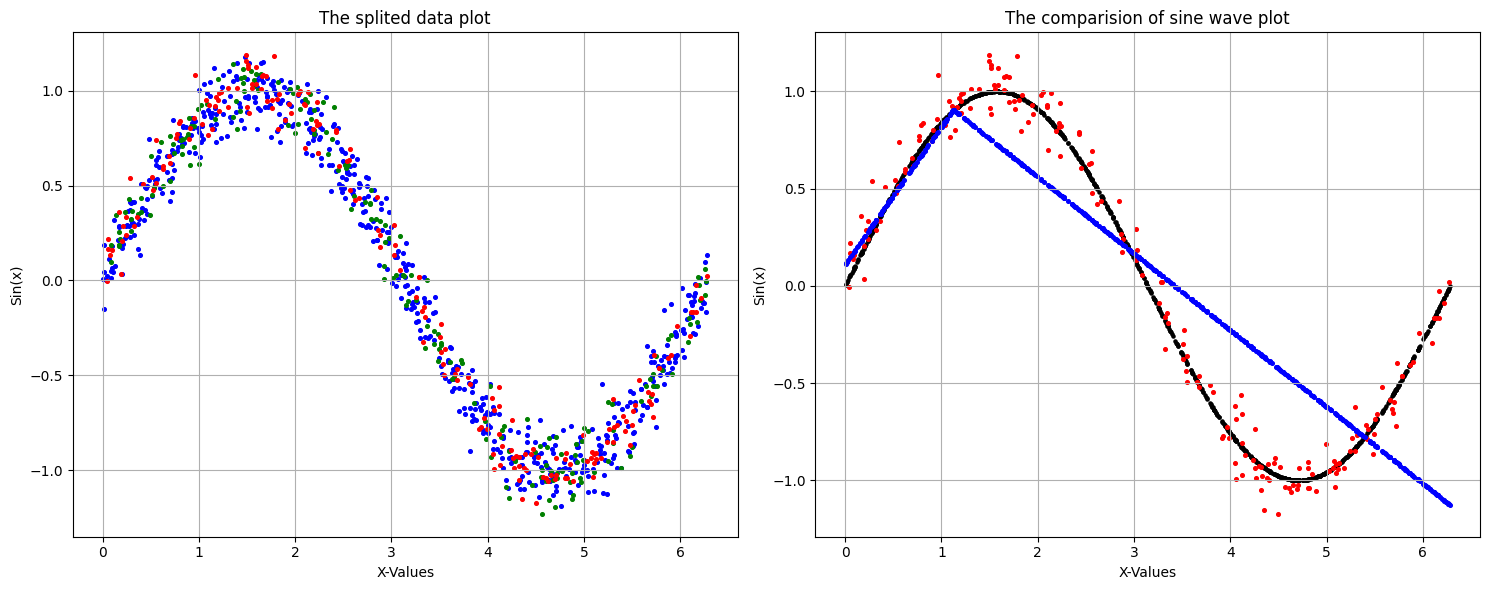

In [7]:
# Plot the data
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].scatter(x_train, y_train, s=7, color="blue")
axes[0].scatter(x_val, y_val, s=7, color="green")
axes[0].scatter(x_test, y_test, s=7, color="red")
axes[0].grid(True)
axes[0].set_title("The splited data plot")
axes[0].set_xlabel("X-Values")
axes[0].set_ylabel("Sin(x)")

axes[1].scatter(x_value, y_value,s=5, color='black')
axes[1].scatter(x_test, y_test, s=7, color="red")
axes[1].scatter(x_train, pred_1, s=7, color="blue")
axes[1].grid(True)
axes[1].set_title("The comparision of sine wave plot")
axes[1].set_xlabel("X-Values")
axes[1].set_ylabel("Sin(x)")

plt.tight_layout()
plt.show()

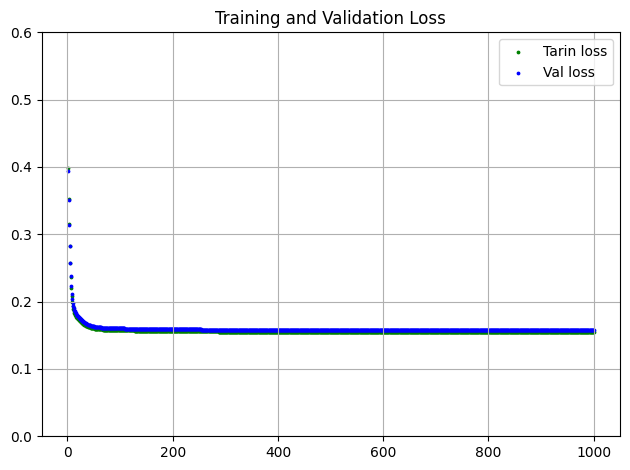

In [8]:
# Plotting the history of the data
loss = history_1.history['loss']
val_loss = history_1.history['val_loss']

epochs = range(1, len(loss)+1)
plt.scatter(epochs, loss, s=3, color='green', label='Tarin loss')
plt.scatter(epochs, val_loss, s=3, color='blue', label='Val loss')
plt.grid(True)
plt.title('Training and Validation Loss')
plt.ylim(0, 0.6)
plt.legend()
plt.tight_layout()
plt.show()

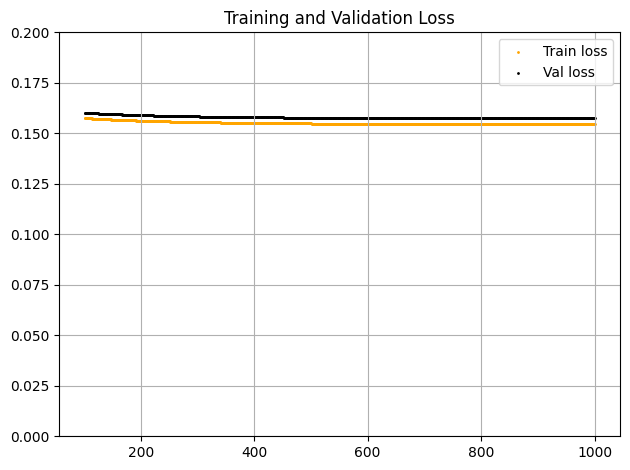

In [9]:
skip=100
plt.scatter(epochs[skip:], loss[skip:], s=1, color='orange', label='Train loss')
plt.scatter(epochs[skip:], val_loss[skip:], s=1, color='black', label='Val loss')
plt.title('Training and Validation Loss')
plt.grid(True)
plt.ylim(0, 0.2)
plt.legend()
plt.tight_layout()
plt.show()

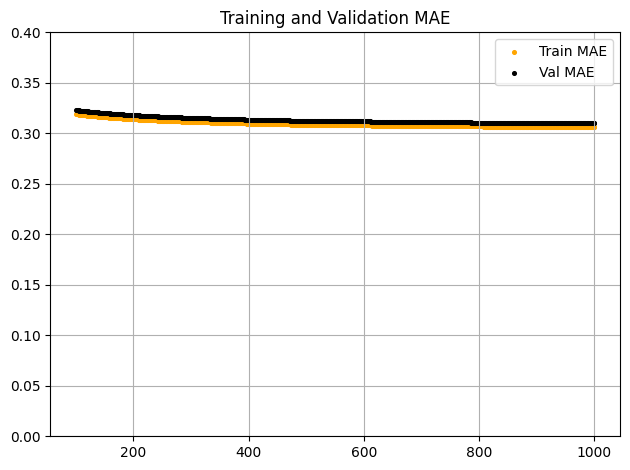

In [10]:
mae = history_1.history['mae']
val_mae= history_1.history['val_mae']
plt.scatter(epochs[skip:], mae[skip:], s=7, color='orange', label='Train MAE')
plt.scatter(epochs[skip:], val_mae[skip:], s=7, color='black', label='Val MAE')
plt.title('Training and Validation MAE')
plt.grid(True)
plt.ylim(0, 0.4)
plt.legend()
plt.tight_layout()
plt.show()


In [11]:
model_2 = tf.keras.Sequential()
model_2.add(layers.Dense(16, activation='relu', input_shape=(1,)))
model_2.add(layers.Dense(16, activation='relu'))
model_2.add(layers.Dense(1))

model_2.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history_2 = model_2.fit(x_train, y_train, epochs=600, 
                        batch_size=16, validation_data=(x_val, y_val))

Epoch 1/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6207 - mae: 0.6512 - val_loss: 0.3807 - val_mae: 0.5328
Epoch 2/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3390 - mae: 0.5052 - val_loss: 0.3305 - val_mae: 0.4958
Epoch 3/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2925 - mae: 0.4707 - val_loss: 0.2830 - val_mae: 0.4581
Epoch 4/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2527 - mae: 0.4381 - val_loss: 0.2451 - val_mae: 0.4264
Epoch 5/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2219 - mae: 0.4107 - val_loss: 0.2169 - val_mae: 0.4011
Epoch 6/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2004 - mae: 0.3895 - val_loss: 0.1976 - val_mae: 0.3818
Epoch 7/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1864 - mae: 0.3732 - val_loss: 0.1853 - val_mae: 0.3683
Epoch 8/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1779 - mae: 0.3616 - val_loss: 0.1776 - val_mae: 0.3593
Epoch 9/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.172

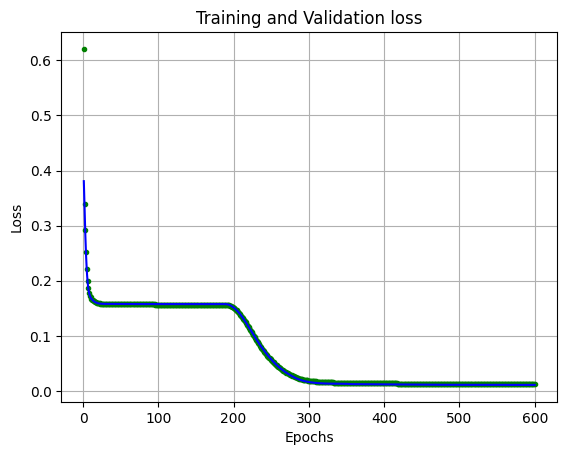

In [13]:
loss = history_2.history['loss']
val_loss = history_2.history['val_loss']
epochs = range(1, len(loss)+1)

plt.plot(epochs, loss, 'g.', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

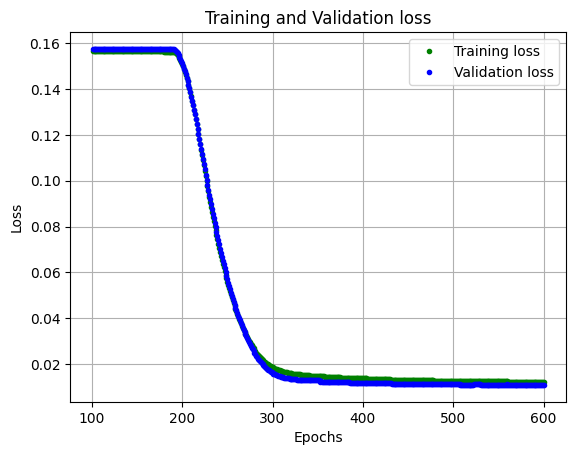

In [14]:
SKIP = 100
plt.clf()
plt.plot(epochs[SKIP:], loss[SKIP:], 'g.', label='Training loss')
plt.plot(epochs[SKIP:], val_loss[SKIP:], 'b.', label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid()
plt.legend()
plt.show()


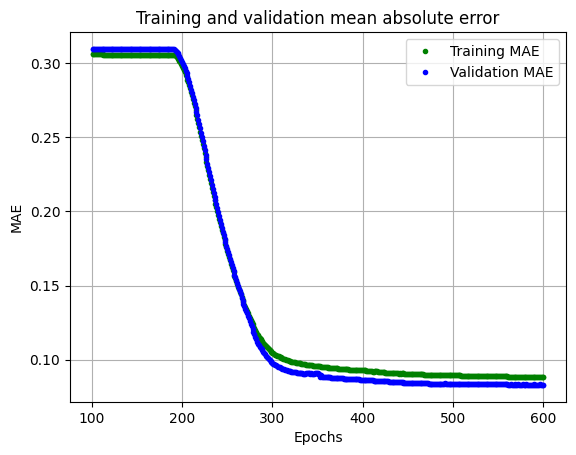

In [15]:
plt.clf()
# Draw a graph of mean absolute error, which is another way of
# measuring the amount of error in the prediction.
mae = history_2.history['mae']
val_mae = history_2.history['val_mae']
plt.plot(epochs[SKIP:], mae[SKIP:], 'g.', label='Training MAE')
plt.plot(epochs[SKIP:], val_mae[SKIP:], 'b.', label='Validation MAE')
plt.title('Training and validation mean absolute error')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.grid(True)
plt.legend()
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0096 - mae: 0.0748 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


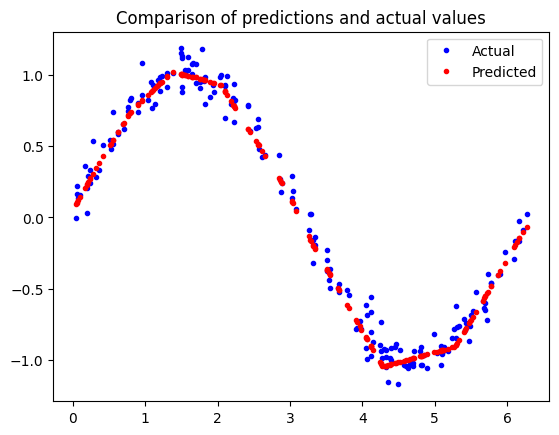

In [16]:
# Calculation of loss on our test dataset
loss = model_2.evaluate(x_test, y_test)
predictions = model_2.predict(x_test)

plt.clf()
plt.title('Comparison of predictions and actual values')
plt.plot(x_test, y_test, 'b.', label='Actual')
plt.plot(x_test, predictions, 'r.', label='Predicted')
plt.legend()
plt.show()